In [13]:
import cv2
from ultralytics import YOLO
import matplotlib.pyplot as plt

In [14]:
# loading trained model

model = YOLO("plate_v1_33_epochs.pt")

In [15]:
# test image

test_image = 'rear_test_images/test4.jpg'
img = cv2.imread(test_image)

In [16]:
# run inference
results = model.predict(source=img, imgsz=640, conf=0.63, verbose=False)

# draw bboxes
for r in results:
    boxes = r.boxes.xyxy.cpu().numpy()      # (x1, y1, x2, y2)
    confs = r.boxes.conf.cpu().numpy()      # confidence scores
    clss = r.boxes.cls.cpu().numpy().astype(int)  # class indices
    names = r.names                          # class name dict

    for box, conf, cls in zip(boxes, confs, clss):
        x1, y1, x2, y2 = box.astype(int)
        label = f"{names[cls]} {conf:.2f}"

        # Draw green bounding box
        cv2.rectangle(img, (x1, y1), (x2, y2), (0, 255, 0), 2)

        # Draw label above box
        cv2.putText(img, label, (x1, y1 - 10),
                    cv2.FONT_HERSHEY_SIMPLEX, 0.6, (0, 255, 0), 2)

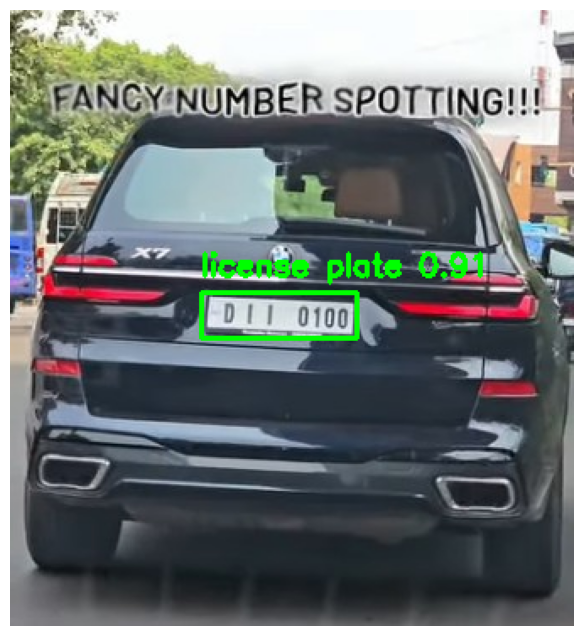

In [17]:
# Convert BGR (OpenCV) → RGB (matplotlib)
img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

# Show inline
plt.figure(figsize=(10, 8))
plt.imshow(img_rgb)
plt.axis("off")
plt.show()